In [1]:
import torch
import sys
sys.path.append('../')
from utilities import load_embedding, print_exams
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [2]:
import torch.nn.functional as F
import os
from tqdm import tqdm

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def monte_carlo_preds(model, dataloader, emb_dict, device, T=20):
    all_preds = []
    all_labels = []
    seed_base = 42
    model.train()
    Total_iter = T*len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Monte Carlo Predictions")
    for t in range(T):
        for batch in dataloader:
            with torch.no_grad():
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]
                matrixs_a, matrixs_b, matrixs_c, matrixs_d= matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)

                torch.manual_seed(seed_base + t)
                torch.cuda.manual_seed_all(seed_base + t)
                
                _, _, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                all_preds.append([item[0].item() for item in output])
                all_labels.append(labels)
                progress_bar.update(1)
    
    progress_bar.close()
    return all_preds, all_labels


In [3]:
device = torch.device('cuda:0')
Crick_train = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/train.csv', index_col=False)
Crick_test = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/test.csv', index_col=False)
Active_data = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/CNIC_all.csv', index_col=False)
Active_data = Active_data.loc[Active_data['virusDate'] <= '2023-08-31']

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Active_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Active_final = Active_data.groupby(group_columns).agg(agg_dict).reset_index()

Active_final['seq_id_a'] = Active_final['seq_id_a'] + '_active'
Active_final['seq_id_b'] = Active_final['seq_id_b'] + '_active'
Active_final['seq_id_c'] = Active_final['seq_id_c'] + '_active'
Active_final['seq_id_d'] = Active_final['seq_id_d'] + '_active'

Active_candidate, Active_test = train_test_split(Active_final, test_size=0.2, random_state=42)

In [4]:
batch_size = 8
Crick_train_dataloader = DataLoader(fluProfiler_Dataset(Crick_train), batch_size=batch_size, shuffle=True)
Crick_test_dataloader = DataLoader(fluProfiler_Dataset(Crick_test), batch_size=batch_size, shuffle=False)
Active_candidate_dataloader = DataLoader(fluProfiler_Dataset(Active_candidate), batch_size=batch_size, shuffle=False)
Active_test_dataloader = DataLoader(fluProfiler_Dataset(Active_test), batch_size=128, shuffle=False)

In [ ]:
# load embedding
emb_dict_active = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_CNIC")
emb_dict_active = {key:value.to(device) for key, value in emb_dict_active.items()}

Loading tensor: 100%|██████████| 1958/1958 [01:23<00:00, 23.55file/s]


## 使用聚类筛选代表性血清

In [75]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Active_candidate_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    matrixs_a, masks_a = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())
result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 1.28751
MSE: 2.84028
pearson correlation: 0.68630
spearman correlation: 0.70858
R2_score: 0.42776


In [7]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

In [76]:
dict_path = '/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=False))
active_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()

In [136]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

kmeans = KMeans(n_clusters=200, random_state=42, n_init=10)
kmeans.fit(active_candidate_tensor)
# centers = kmeans.cluster_centers_
centers = kmeans.cluster_centers_[pd.Series(kmeans.labels_).value_counts()[:40].index.tolist()]
distances = cdist(centers, active_candidate_tensor)
representative = distances.argmin(axis=1)

active_selection = Active_candidate.iloc[representative]
random_selection = Active_candidate.sample(active_selection.shape[0], random_state=42)

active_dataloader = DataLoader(fluProfiler_Dataset(active_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection), batch_size=8, shuffle=False)

In [137]:
dd = Active_candidate.copy()
dd['cluster'] = pd.Series(kmeans.labels_).tolist()
selected_cluster = pd.Series(kmeans.labels_).value_counts()[:50].index
dd = dd[dd['cluster'].isin(selected_cluster)]

active_selection = dd.groupby('cluster', group_keys=False).apply(lambda x: x.sample(frac=200/dd.shape[0]))
random_selection = Active_candidate.sample(active_selection.shape[0], random_state=42)

active_dataloader = DataLoader(fluProfiler_Dataset(active_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection), batch_size=8, shuffle=False)

/tmp/ipykernel_3692856/3088376556.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  active_selection = dd.groupby('cluster', group_keys=False).apply(lambda x: x.sample(frac=200/dd.shape[0]))


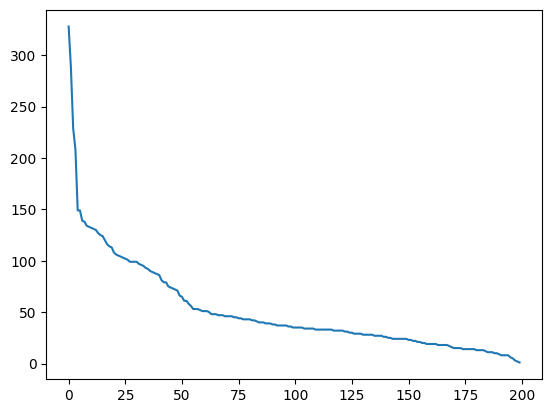

In [96]:
import matplotlib.pyplot as plt
plt.plot(pd.Series(kmeans.labels_).value_counts().tolist())
plt.show()

In [44]:
candidate_serum = Active_candidate.loc[Active_candidate['seq_a'].str.len() == 566, :]
selected_serum = (candidate_serum.value_counts(['seq_a']) >= 30).reset_index()
selected_serum = selected_serum[selected_serum['count'] == True]
candidate_serum = candidate_serum[candidate_serum['seq_a'].isin(selected_serum['seq_a'])].drop_duplicates(['seq_a', 'seq_b'])

In [46]:
vector_candidate = np.stack([np.asarray(emb_dict_active[(('matrix_'+str(HA_name)).replace('_active', ''))].max(axis=0)[0].to('cpu')) for HA_name in candidate_serum['seq_id_a']])

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(vector_candidate)
centers = kmeans.cluster_centers_
distances = cdist(centers, vector_candidate)
representative = distances.argmin(axis=1)

# active_selected = Crick41_candidate.iloc[representative]
# Crick41_random_selected = Crick41_candidate.sample(500, random_state=42)
# pca = PCA(n_components=3, random_state=42)
# X_3d = pca.fit_transform(np.vstack([vector_candidate, vector_test]))

In [92]:
labels

tensor([7., 4.], device='cuda:0')

In [60]:
active_serum = candidate_serum.iloc[representative][['seq_a', 'seq_b']]
random_serum = candidate_serum.sample(active_serum.shape[0], random_state=42)[['seq_a', 'seq_b']]

active_selection = active_serum.merge(Active_candidate, on=['seq_a', 'seq_b'], how='left')
active_group = active_selection.groupby(['seq_a', 'seq_b'])
active_selection = active_group.apply(lambda x: x.sample(n=30, random_state=42), include_groups=False).reset_index(drop=True)

random_selection = random_serum.merge(Active_candidate, on=['seq_a', 'seq_b'], how='left')
random_group = random_selection.groupby(['seq_a', 'seq_b'])
random_selection = random_group.apply(lambda x: x.sample(n=30, random_state=42), include_groups=False).reset_index(drop=True)

active_dataloader = DataLoader(fluProfiler_Dataset(active_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection), batch_size=8, shuffle=False)

In [61]:
print(active_selection.shape)
print(random_selection.shape)

(300, 20)
(300, 20)


In [62]:
def multidata_trainer(model, train_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    MAE_ls = []
    MSE_ls = []
    Pearson_ls = []
    Spearman_ls = []
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls)
        MAE_ls.append(test_mae)
        MSE_ls.append(test_mse)
        Pearson_ls.append(test_pearson)
        Spearman_ls.append(test_spearman)


        epochs = list(range(1, len(MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, MSE_ls, label='CDC MSE', marker='o')

        plt.text(epochs[-1], MSE_ls[-1], f'{MSE_ls[-1]:.5f}', ha='center', va='bottom')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [MAE_ls, MSE_ls, Pearson_ls, Spearman_ls, R2]

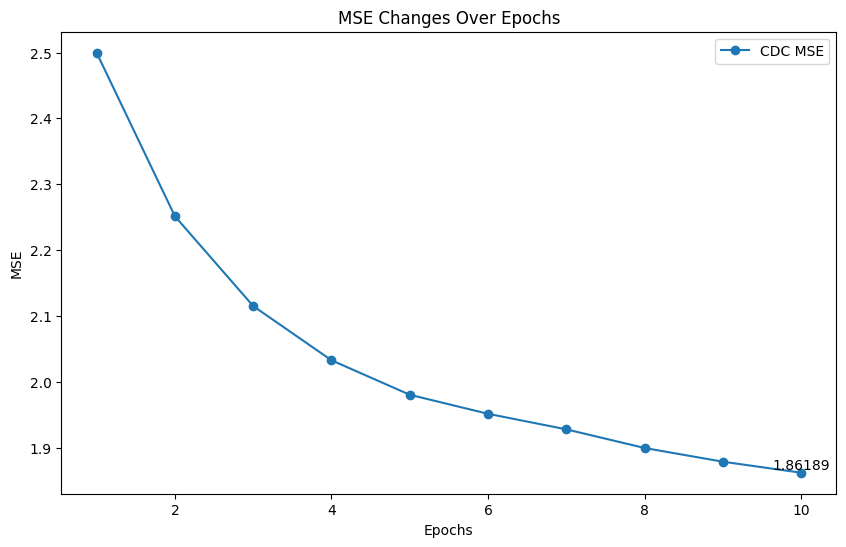

In [131]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, active_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

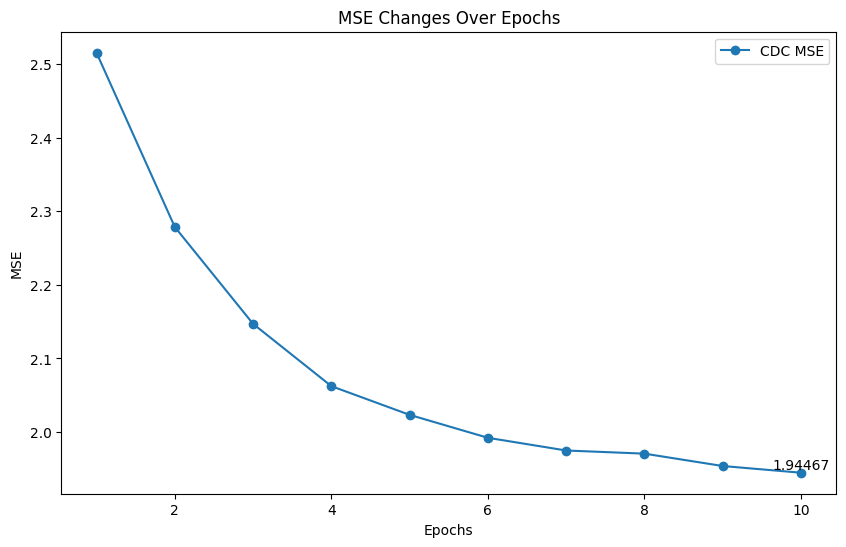

In [138]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, active_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

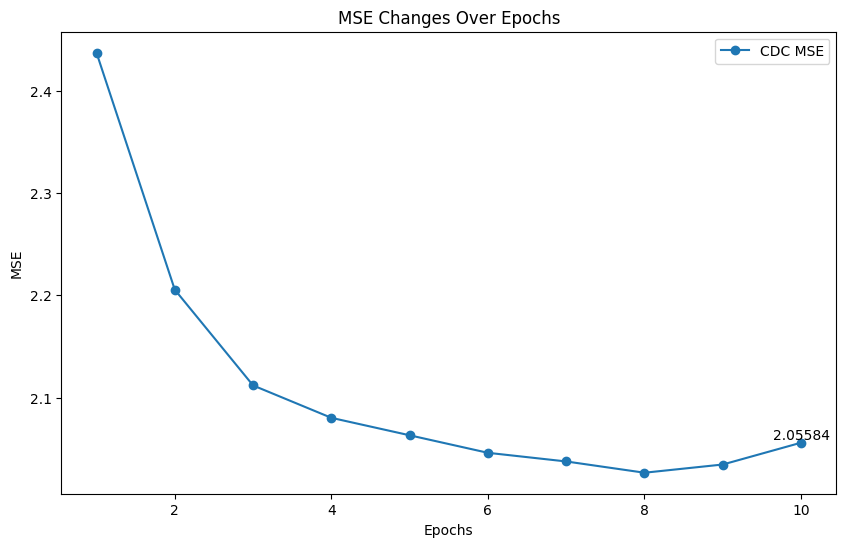

In [132]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

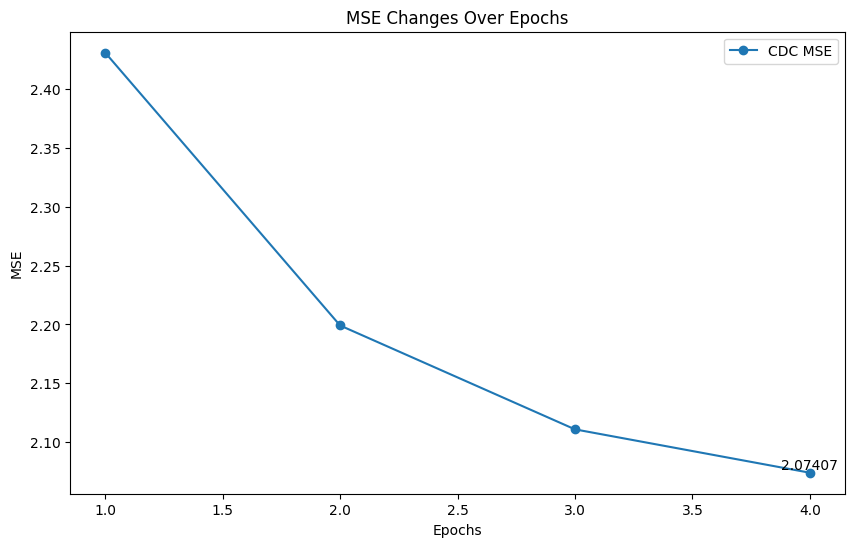

KeyboardInterrupt: 

: 

In [ ]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

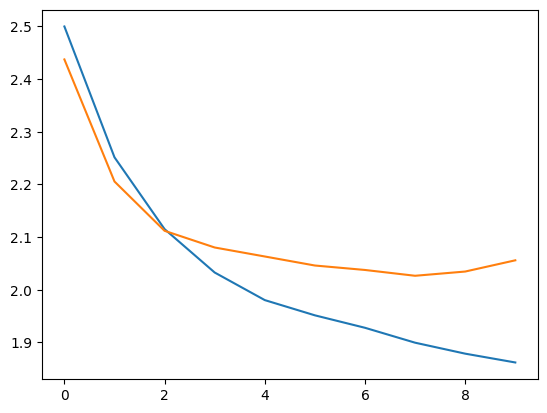

In [135]:
plt.plot(active_result[1])
plt.plot(random_result[1])

In [70]:
random_result[0]

[1.1988665990856955,
 1.1596981060222804,
 1.1416262068628398,
 1.1291319530630863,
 1.1235416450727622,
 1.1244600072597126,
 1.118748175531481,
 1.1179149288640728,
 1.1216129216645818,
 1.117401536264032]

In [ ]:
pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(vector_candidate)

In [ ]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame(X_3d, columns=['x', 'y', 'z'])
df['cluster'] = labels.astype(str)
# df['type'] = candidate['Type'].tolist()
df['type'] = labels
df['virusDate'] = candidate['virusDate'].tolist()
df['virusIslID'] = candidate['virusIslID'].tolist()

color_map = {
    'candidate':    'yellow',   # 鲜红（实色）
    'test':    'red',   # 深蓝（实色）
}

fig = px.scatter_3d(
        df, x='x', y='y', z='z',
        color='type',
        color_discrete_map=color_map,
        opacity=0.8,
        hover_data={'virusDate': True,   # 显示日期
                    'cluster': True,
                    'virusIslID': True},  
        title='3D clustering (Red vs Blue)'
)

fig.update_traces(marker=dict(size=4))
fig.show()

## 使用Monte Carlo dropout筛选血清

In [ ]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
                   
dropout_rate = 0.5
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = dropout_rate

In [ ]:
trainS_preds, trainS_labels = monte_carlo_preds(model, Active_test_dataloader, emb_dict_active, device, T=20)

Monte Carlo Predictions: 100%|██████████| 6440/6440 [04:13<00:00, 25.39it/s]


In [ ]:
pred_df = list2df(trainS_preds,len(Active_test_dataloader))
var = pred_df.var(axis=0) / pred_df.mean(axis=0)
uncertainty_df = Active_test.copy().reset_index(drop=True)
uncertainty_df['var'] = var
uncertainty_df['prediction'] = test_prediction_ls
# uncertainty_df.to_csv('./Data/uncertainty_round1.csv', index=False)

In [ ]:
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Active_test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())

result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 1.30558
MSE: 2.94864
pearson correlation: 0.66990
spearman correlation: 0.69476
R2_score: 0.41144


In [ ]:
print_exams(uncertainty_df['label']-uncertainty_df['prediction']/(uncertainty_df['label'] + uncertainty_df['label'].mean()), uncertainty_df['var'])

MAE: 2.33158
MSE: 8.93984
pearson correlation: -0.13190
spearman correlation: -0.40997
R2_score: -15.40518


(2.3315755334799744,
 8.939839207650094,
 PearsonRResult(statistic=-0.13190275278784447, pvalue=1.8239764046534822e-11),
 SignificanceResult(statistic=-0.4099650103660234, pvalue=5.941147402668094e-105),
 -15.40518159009169)

In [ ]:
uncertainty_df.to_csv('./Data/uncertainty_round1.csv', index=False)

In [ ]:
uncertainty_selection = dd.sort_values(by='var', ascending=False).iloc[:500,:]
ramdom_selection = Active_candidate.sample(uncertainty_selection.shape[0], random_state=42)

uncertainty_dataloader = DataLoader(fluProfiler_Dataset(uncertainty_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(ramdom_selection), batch_size=8, shuffle=False)

In [ ]:
# df = dd.groupby(['seq_a', 'seq_b', 'serumPassCat']).agg({'Type': 'first', 'var': 'mean'}).reset_index().sort_values(by='var', ascending=False)
# uncertainty_serum = df.iloc[:5,][['seq_a', 'seq_b', 'serumPassCat']]
# random_serum = df.sample(6, random_state=42)[['seq_a', 'seq_b', 'serumPassCat']]
# uncertainty_selection = uncertainty_serum.merge(Active_candidate, on=['seq_a', 'seq_b', 'serumPassCat'], how='left')
# ramdom_selection = random_serum.merge(Active_candidate, on=['seq_a', 'seq_b', 'serumPassCat'], how='left')

# uncertainty_dataloader = DataLoader(fluProfiler_Dataset(uncertainty_selection), batch_size=8, shuffle=False)
# random_dataloader = DataLoader(fluProfiler_Dataset(ramdom_selection), batch_size=8, shuffle=False)

In [ ]:
def multidata_trainer(model, train_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    MAE_ls = []
    MSE_ls = []
    Pearson_ls = []
    Spearman_ls = []
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls)
        MAE_ls.append(test_mae)
        MSE_ls.append(test_mse)
        Pearson_ls.append(test_pearson)
        Spearman_ls.append(test_spearman)


        epochs = list(range(1, len(MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, MSE_ls, label='CDC MSE', marker='o')

        plt.text(epochs[-1], MSE_ls[-1], f'{MSE_ls[-1]:.5f}', ha='center', va='bottom')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [MAE_ls, MSE_ls, Pearson_ls, Spearman_ls, R2]

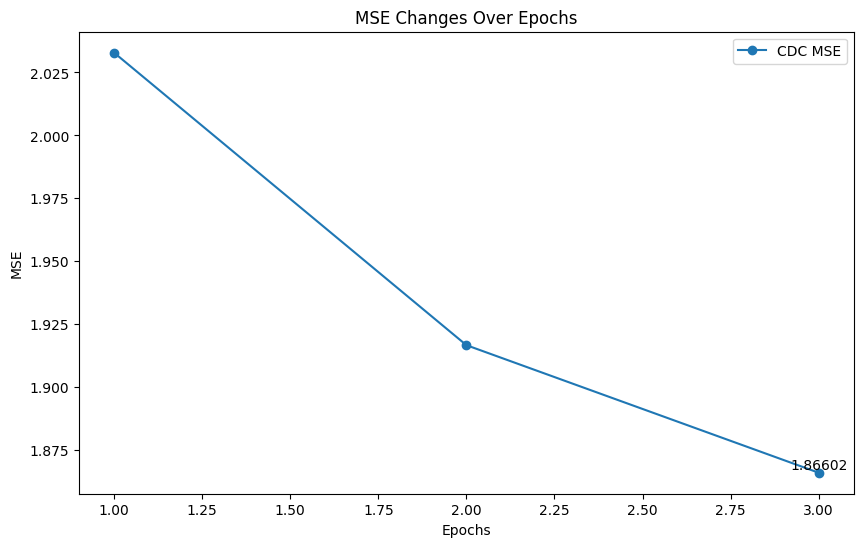

KeyboardInterrupt: 

In [ ]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, uncertainty_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

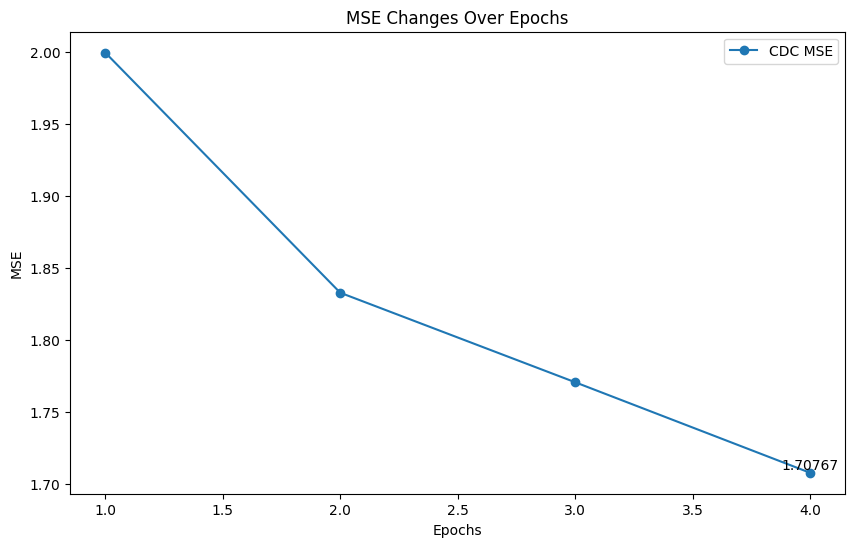

KeyboardInterrupt: 

In [ ]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

## 比较使用特征向量聚类后，提取代表性序列

In [ ]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth',
                   weights_only=False, map_location=device)
dropout_rate = 0.1
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = dropout_rate

In [ ]:
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Active_test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())

result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 1.27138
MSE: 2.81509
pearson correlation: 0.68730
spearman correlation: 0.71456
R2_score: 0.42498


In [ ]:
dd = Active_test.copy()
dd['prediction'] = test_prediction_ls
print_exams(dd[dd['Type'] == 'H1N1']['prediction'], dd[dd['Type'] == 'H1N1']['label'])
print_exams(dd[dd['Type'] == 'H3N2']['prediction'], dd[dd['Type'] == 'H3N2']['label'])

MAE: 1.22173
MSE: 2.85651
pearson correlation: 0.78702
spearman correlation: 0.64270
R2_score: 0.56093
MAE: 1.29993
MSE: 2.79126
pearson correlation: 0.54582
spearman correlation: 0.53993
R2_score: 0.19283


(1.2999335080523702,
 2.791262199126056,
 PearsonRResult(statistic=0.5458164195917402, pvalue=9.570452349744158e-127),
 SignificanceResult(statistic=0.5399260544301454, pvalue=1.5117278974186072e-123),
 0.19283330289156753)

In [ ]:
dict_path = '/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=True))
Active_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

kmeans = KMeans(n_clusters=500, random_state=42, n_init=10)
kmeans.fit(Crick41_candidate_tensor)
centers = kmeans.cluster_centers_
distances = cdist(centers, Crick41_candidate_tensor)
representative = distances.argmin(axis=1)

Crick41_active_selected = Crick41_candidate.iloc[representative]
Crick41_random_selected = Crick41_candidate.sample(500, random_state=42)

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
model_random.to(device)

def multidata_trainer(model, train_data, selected_data, lr_rate, epoch=20):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    CDC_MAE_ls = []
    CDC_MSE_ls = []
    CDC_Pearson_ls = []
    CDC_Spearman_ls = []
    Crick_MAE_ls = []
    Crick_MSE_ls = []
    Crick_Pearson_ls = []
    Crick_Spearman_ls = []
    for epoch in range(epoch):
        # old_data = train_data.sample(1000, random_state=epoch+1)
        # new_dataset = fluProfiler_Dataset(pd.concat([old_data, selected_data]))
        new_dataset = fluProfiler_Dataset(selected_data)
        new_dataloader = DataLoader(new_dataset, batch_size=8, shuffle=True)
        model.train()
        loss_ls = []
        for batch in new_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict_41[key.replace('_future', '')] if key.endswith('_future') else emb_dict_Crick[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict_41[key.replace('_future', '')] if key.endswith('_future') else emb_dict_Crick[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict_41[key.replace('_future', '')] if key.endswith('_future') else emb_dict_Crick[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict_41[key.replace('_future', '')] if key.endswith('_future') else emb_dict_Crick[key] for key in emb_file_name_d])

            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        CDC_test_prediction_ls = []
        CDC_test_reference_ls = []
        CDC_test_logits_ls = []
        model.eval()
        for batch in Crick41_test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict_41[key.replace('_future', '')] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict_41[key.replace('_future', '')] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict_41[key.replace('_future', '')] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict_41[key.replace('_future', '')] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            CDC_test_prediction_ls = CDC_test_prediction_ls + output.view(-1).tolist()
            CDC_test_reference_ls = CDC_test_reference_ls + labels.tolist()
            CDC_test_logits_ls.append(logits.tolist())
        
        CDC_test_mae, CDC_test_mse, CDC_test_pearson, CDC_test_spearman, CDC_R2 = print_exams(CDC_test_reference_ls, CDC_test_prediction_ls)
        CDC_MAE_ls.append(CDC_test_mae)
        CDC_MSE_ls.append(CDC_test_mse)
        CDC_Pearson_ls.append(CDC_test_pearson)
        CDC_Spearman_ls.append(CDC_test_spearman)

        ## 每5个epoch在Crick上测试一次

        if epoch % 5 == 0:
            Crick_test_prediction_ls = []
            Crick_test_reference_ls = []
            Crick_test_logits_ls = []
            model.eval()
            for batch in Crick_test_dataloader:
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict_Crick[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict_Crick[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict_Crick[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict_Crick[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)
                with torch.no_grad():
                    loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                                matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                                matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                Crick_test_prediction_ls = Crick_test_prediction_ls + output.view(-1).tolist()
                Crick_test_reference_ls = Crick_test_reference_ls + labels.tolist()
                Crick_test_logits_ls.append(logits.tolist())

            Crick_test_mae, Crick_test_mse, Crick_test_pearson, Crick_test_spearman, Crick_test_R2  = print_exams(Crick_test_prediction_ls, Crick_test_reference_ls)
            Crick_MAE_ls.append(Crick_test_mae)
            Crick_MSE_ls.append(Crick_test_mse)
            Crick_Pearson_ls.append(Crick_test_pearson)
            Crick_Spearman_ls.append(Crick_test_spearman)
    
        epochs = list(range(1, len(CDC_MSE_ls)+1))
        Crick_epochs = [i for i in range(1, len(Crick_MSE_ls)+1)]

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, CDC_MSE_ls, label='CDC MSE', marker='o')
        plt.plot(Crick_epochs, Crick_MSE_ls, label='Crick MSE', marker='x')

        plt.text(epochs[-1], CDC_MSE_ls[-1], f'{CDC_MSE_ls[-1]:.5f}', ha='center', va='bottom')
        plt.text(Crick_epochs[-1], Crick_MSE_ls[-1], f'{Crick_MSE_ls[-1]:.5f}', ha='center', va='top')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [CDC_MAE_ls, Crick_MAE_ls, CDC_MSE_ls, Crick_MSE_ls, CDC_Pearson_ls, Crick_Pearson_ls, CDC_Spearman_ls, Crick_Spearman_ls]

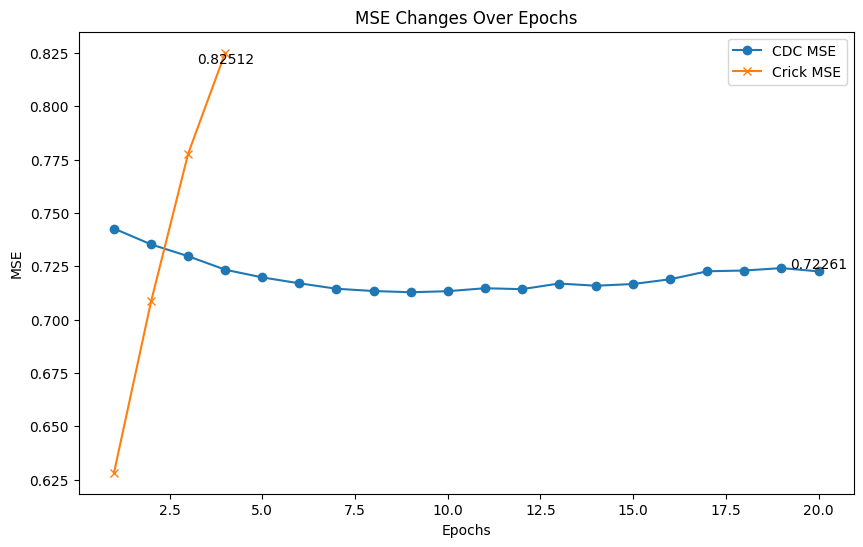

In [ ]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, Crick_train, Crick41_active_selected, lr_rate=0.00002, epoch=20)

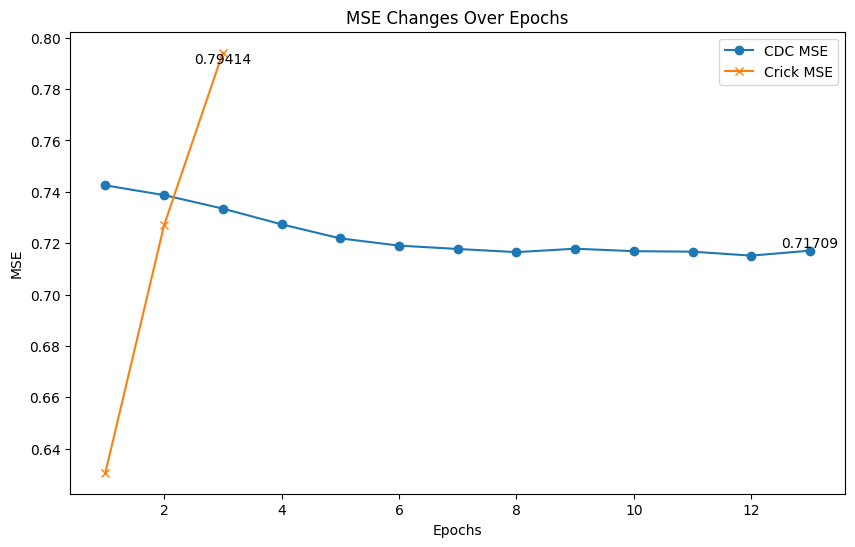

In [ ]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_random, Crick_train, Crick41_random_selected, lr_rate=0.00002, epoch=20)

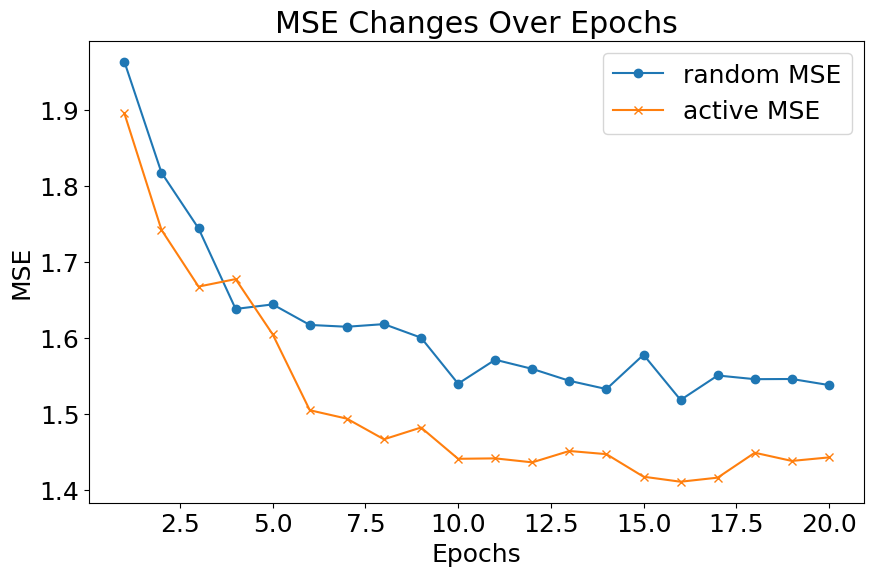

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(list(range(1, len(random_CDC_MSE)+1)), random_CDC_MSE, label='random MSE', marker='o')
plt.plot(list(range(1, len(active_CDC_MSE)+1)), active_CDC_MSE, label='active MSE', marker='x')

# for i in range(len(random_CDC_MSE)):
#     plt.text(i, random_CDC_MSE[i], f'{random_CDC_MSE[i]:.2f}', ha='center', va='bottom')
#     plt.text(i, active_CDC_MSE[i], f'{active_CDC_MSE[i]:.2f}', ha='center', va='top')

# 添加标题和标签
plt.title('MSE Changes Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
clear_output(wait=True)
plt.show()

## Comprehensive

In [ ]:
# load embedding
emb_list = pd.concat([CDC_all_final['seq_id_a'], CDC_all_final['seq_id_b'], CDC_all_final['seq_id_c'], CDC_all_final['seq_id_d']], axis=0).unique().tolist()
emb_list = ['matrix_' + item +'.pt' for item in emb_list]
IDs, embeddings = load_embedding("/data/chenyihao/embedding", files=emb_list)
embeddings = [emb.to(device) for emb in embeddings]
emb_dict = dict(zip(IDs, embeddings))

Loading tensor: 100%|██████████| 1757/1757 [04:13<00:00,  6.93file/s]


In [ ]:
dropout_rate = 0.5
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = dropout_rate

CDC_sample_dataloader = DataLoader(LucaDataset(CDC_candidate), batch_size=80)
CDCS_preds, CDCS_labels = monte_carlo_preds(model, CDC_sample_dataloader, T=20)

In [ ]:
CDC_pred_df = list2df(CDCS_preds,len(CDC_sample_dataloader))
CDC_var = CDC_pred_df.var(axis=0)
print('The mean variance of test set is: ', CDC_var.mean())

The mean variance of test set is:  0.4657105126649325


In [ ]:
test_df = CDC_candidate.copy()
test_df['uncertainty'] = CDC_var.tolist()

H1N1_uncertainty = test_df[test_df['serumType'] == 'H1N1']['uncertainty']
H3N2_uncertainty = test_df[test_df['serumType'] == 'H3N2']['uncertainty']
print(H1N1_uncertainty.mean())
print(H3N2_uncertainty.mean())

0.4111977291719905
0.4954049883863767


In [ ]:
from scipy import stats

levene_stat, levene_p = stats.levene(H1N1_uncertainty, H3N2_uncertainty)
print("Levene p =", levene_p)
equal_var = levene_p > 0.05   # >0.05 认为方差齐

t_stat, p_val = stats.ttest_ind(H1N1_uncertainty, H3N2_uncertainty, equal_var=equal_var)
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

Levene p = 0.10768673370105787
t = -15.064, p = 0.0000


In [ ]:
serumNames = test_df['serumName'].unique().tolist()

serum_Uncertainty = []
for serum in serumNames:
    serum_Uncertainty.append(test_df[test_df['serumName'] == serum]['uncertainty'].mean())

Uncertainty_dict = {key: value for key, value in zip(serumNames, serum_Uncertainty)}

In [ ]:
top10 = dict(sorted(Uncertainty_dict.items(), key=lambda x: x[1], reverse=True)[:10])

In [ ]:
import importlib
import model_001
importlib.reload(model_001)
from model_001 import *

In [ ]:
del model

In [ ]:
model = torch.load('/data/chenyihao/fluProfiler_source/model/model_001.pth', weights_only=False, map_location=device)

In [ ]:
filted_sample = CDC_candidate[CDC_candidate['serumName'].isin(top10.keys())].copy()
print(len(filted_sample))
Dataset_4_concat_vector = LucaDataset(filted_sample)
Dataloader_4_concat_vector = DataLoader(Dataset_4_concat_vector, batch_size=100, shuffle=False)

2331


In [ ]:
from utilities import print_exams

test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Dataloader_4_concat_vector:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
    
    # matrixs_a = matrixs_a.to(device)
    # matrixs_b = matrixs_b.to(device)
    # matrixs_c = matrixs_c.to(device)
    # matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/data/chenyihao/fluProfiler_source/data/processed/3.1')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())

print_exams(test_prediction_ls, test_reference_ls)

MAE:  1.2479186165919636
MSE:  2.519025994714801
pearson correlation:  PearsonRResult(statistic=0.5781270822759106, pvalue=5.203192254088627e-208)
spearman correlation:  SignificanceResult(statistic=0.5473255580398375, pvalue=2.5720816766868268e-182)
R2_score:  0.276612947557176


In [ ]:
dict_path = '/data/chenyihao/fluProfiler_source/data/processed/3.1'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=False))
CDC_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()
print(CDC_candidate_tensor.shape)

(2331, 1024)


In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

kmeans = KMeans(n_clusters=500, random_state=42, n_init=10)
kmeans.fit(CDC_candidate_tensor)
centers = kmeans.cluster_centers_
distances = cdist(centers, CDC_candidate_tensor)
representative = distances.argmin(axis=1)

CDC_active_selected = CDC_candidate.iloc[representative]
CDC_random_selected = CDC_candidate.sample(500, random_state=42)

In [ ]:
CDC_active_dataloader = DataLoader(LucaDataset(CDC_active_selected), batch_size=8, shuffle=True)

In [ ]:
import numpy as np
del model

In [ ]:
import pickle

model = torch.load('/data/chenyihao/fluProfiler_source/model/model_001.pth', weights_only=False, map_location=device)
with open("../Section1_BestPractice/1.6_Pretrained_model_compare/args.pkl", "rb") as file:
    fluProfiler_args = pickle.load(file)

no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
optimizer_grouped_parameters = [{
            "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
            "weight_decay": fluProfiler_args.weight_decay
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
            "weight_decay": 0.0
        }
    ]
optimizer = AdamW(optimizer_grouped_parameters,
                    lr=0.00008,
                    betas=[fluProfiler_args.beta1 if fluProfiler_args.beta1 > 0 else 0.9, fluProfiler_args.beta2 if fluProfiler_args.beta2 > 0 else 0.98],
                    eps=fluProfiler_args.adam_epsilon)

epochs = 20

num_training_steps = len(CDC_active_dataloader) * epochs
progress_bar = tqdm(range(num_training_steps)) 

for epoch in range(epochs):
    model.train()
    loss_ls = []
    for batch in CDC_active_dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

        matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
        
        # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
        masks_a = masks_a.to(device)
        masks_b = masks_b.to(device)
        masks_c = masks_c.to(device)
        masks_d = masks_d.to(device)

        strainPassCats = strainPassCats.to(device)

        labels = labels.to(device)
        
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                     matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                     matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, 
                                     strainPassCats=strainPassCats, labels=labels)
    
        loss.backward()
        loss_ls.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()
        progress_bar.update(1)
    train_loss = np.mean(loss_ls)
    print('train loss :', train_loss)

    prediction_ls = []
    reference_ls = []
    logits_ls = []
    loss_ls_valid = []
    model.eval()
    for batch in CDC_test_dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
        
        matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

        # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
        masks_a = masks_a.to(device)
        masks_b = masks_b.to(device)
        masks_c = masks_c.to(device)
        masks_d = masks_d.to(device)

        strainPassCats = strainPassCats.to(device)

        labels = labels.to(device)
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                         matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                         matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                         labels=labels)
    
        loss_ls_valid.append(loss.item())
        logits_ls.append(logits.tolist())
        prediction_ls = prediction_ls + output.view(-1).tolist()
        reference_ls = reference_ls + labels.tolist()

    print_exams(reference_ls, prediction_ls)

  5%|▍         | 62/1260 [00:05<01:45, 11.32it/s]

train loss : 1.901497194218257


  5%|▌         | 64/1260 [00:21<50:04,  2.51s/it]

MAE:  1.0399863313689066
MSE:  1.8542947360441067
pearson correlation:  PearsonRResult(statistic=0.7613846506858506, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.7638977423790425, pvalue=0.0)
R2_score:  0.39453270560635123


 10%|█         | 126/1260 [00:27<01:34, 12.03it/s]

...

train loss : 0.47613974944466636


 95%|█████████▌| 1198/1260 [06:55<03:03,  2.96s/it]

MAE:  0.9123940636709265
MSE:  1.4468753770166172
pearson correlation:  PearsonRResult(statistic=0.8232726572741003, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.8157358088594718, pvalue=0.0)
R2_score:  0.5782149766209432


100%|██████████| 1260/1260 [07:01<00:00, 11.68it/s]

train loss : 0.4571834540674611
MAE:  0.9003139719842838
MSE:  1.4251057602843133
pearson correlation:  PearsonRResult(statistic=0.822997169320426, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.8154689392545875, pvalue=0.0)
R2_score:  0.5860906995559002
